In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [6]:
import requests
import pandas as pd

url = "https://api.coingecko.com/api/v3/coins/markets"

params = {
    "vs_currency": "usd",
    "ids": "bitcoin,ethereum,solana"
}

response = requests.get(url, params=params)

data = response.json()

df = pd.DataFrame(data)

print(df[[
    "name",
    "current_price",
    "market_cap",
    "price_change_percentage_24h"
]])

       name  current_price     market_cap  price_change_percentage_24h
0   Bitcoin       63681.00  1276726653970                      0.55587
1  Ethereum        1663.89   200885142436                     -0.90540
2    Solana          67.11    38913225453                      0.40801


In [7]:
df.to_csv("crypto_data.csv", index=False)

In [8]:
print("Highest Price Coin:")
print(df.loc[df["current_price"].idxmax(), "name"])

print("Average Price:")
print(df["current_price"].mean())

Highest Price Coin:
Bitcoin
Average Price:
21804.0


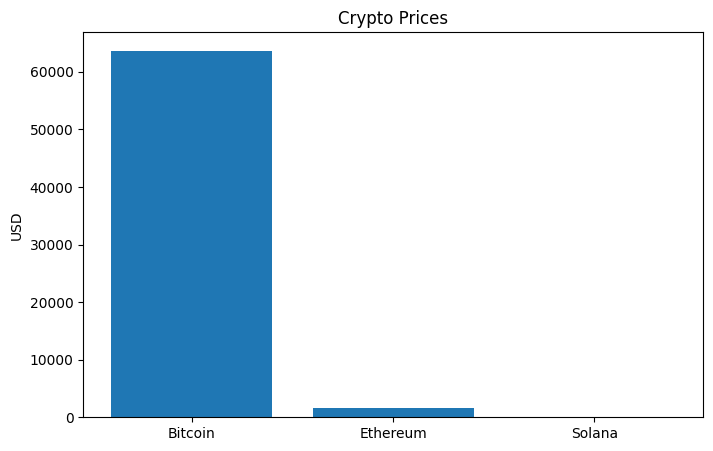

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    df["name"],
    df["current_price"]
)

plt.title("Crypto Prices")
plt.ylabel("USD")

plt.show()

In [10]:
import requests
import pandas as pd

url = "https://api.coingecko.com/api/v3/coins/bitcoin/market_chart"

params = {
    "vs_currency": "usd",
    "days": "30",
    "interval": "daily"
}

response = requests.get(url, params=params)

data = response.json()

prices = data["prices"]

df = pd.DataFrame(prices, columns=["timestamp", "price"])

df["date"] = pd.to_datetime(df["timestamp"], unit="ms")

df = df[["date", "price"]]

print(df.head())

        date         price
0 2026-05-14  79277.804518
1 2026-05-15  81051.982888
2 2026-05-16  79068.820240
3 2026-05-17  78135.009949
4 2026-05-18  77425.715192


In [11]:
df["MA_7"] = df["price"].rolling(7).mean()

print(df.tail())

                  date         price          MA_7
26 2026-06-09 00:00:00  63078.440495  63226.383766
27 2026-06-10 00:00:00  61658.311991  62513.306104
28 2026-06-11 00:00:00  61492.514390  62151.966852
29 2026-06-12 00:00:00  63552.300870  62117.116349
30 2026-06-12 18:31:58  63721.139381  62517.022772


In [12]:
print("Highest Price:")
print(df["price"].max())

print("Lowest Price:")
print(df["price"].min())

print("Average Price:")
print(df["price"].mean())

Highest Price:
81051.9828878728
Lowest Price:
60861.88012897632
Average Price:
71579.27612133783


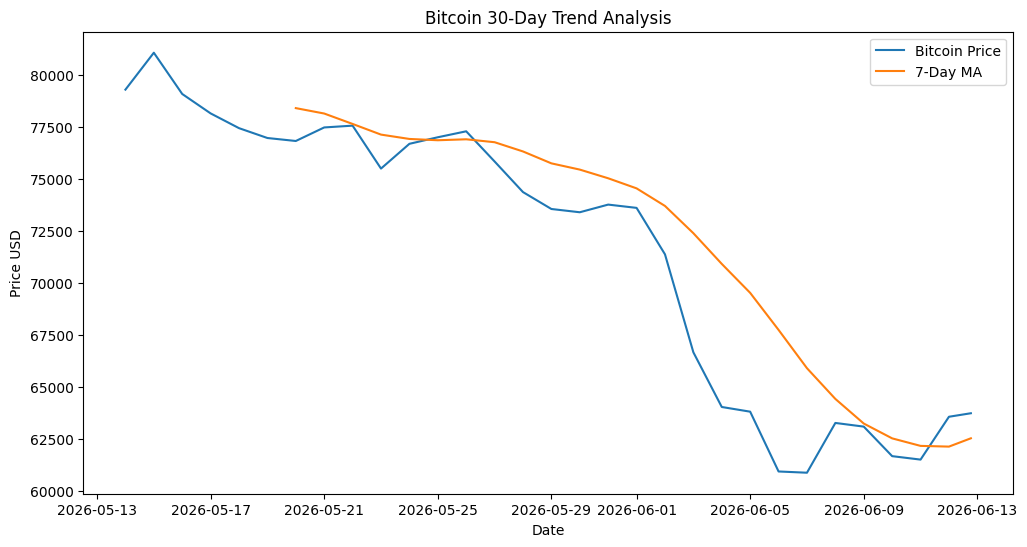

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(df["date"], df["price"], label="Bitcoin Price")

plt.plot(df["date"], df["MA_7"], label="7-Day MA")

plt.title("Bitcoin 30-Day Trend Analysis")

plt.xlabel("Date")

plt.ylabel("Price USD")

plt.legend()

plt.show()

In [14]:
df.to_csv("bitcoin_30day_analysis.csv", index=False)

In [21]:
import requests
import pandas as pd

url = "https://api.coingecko.com/api/v3/coins/markets"

params = {
    "vs_currency": "usd",
    "ids": "bitcoin,ethereum,solana,binancecoin"
}

response = requests.get(url, params=params)
data = response.json()

print("Raw Data Type:", type(data))
print("Length:", len(data))

df = pd.DataFrame(data)

df = df[["name", "current_price", "market_cap", "price_change_percentage_24h"]]

print(df)

Raw Data Type: <class 'list'>
Length: 4
       name  current_price     market_cap  price_change_percentage_24h
0   Bitcoin       63825.00  1279318278557                      0.58006
1  Ethereum        1670.57   201616205221                     -0.76875
2       BNB         607.05    81849810407                      0.40183
3    Solana          67.34    39055522817                      0.78866


In [22]:
df["Score"] = (
    (df["market_cap"] / df["market_cap"].max()) * 50 +
    (df["price_change_percentage_24h"] * 10)
)

df = df.sort_values("Score", ascending=False)

print(df[["name", "Score"]])

       name      Score
0   Bitcoin  55.800600
3    Solana   9.413019
2       BNB   7.217262
1  Ethereum   0.192330


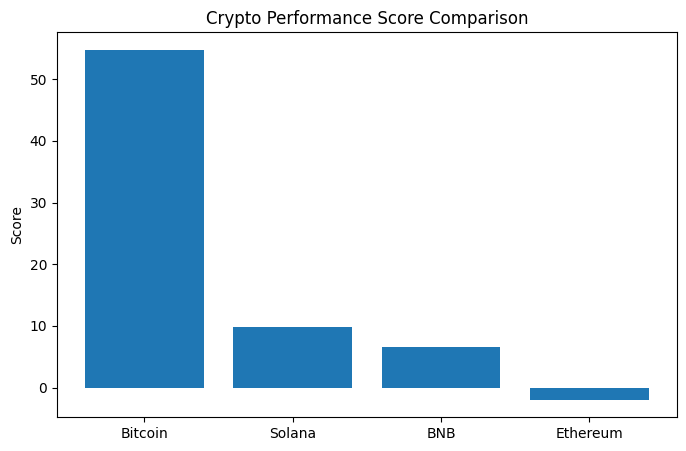

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(df["Coin"], df["Score"])

plt.title("Crypto Performance Score Comparison")

plt.ylabel("Score")

plt.show()